<a href="https://colab.research.google.com/github/Yelitza22/Proyecto-semi/blob/main/deteccion_anomalias_tags(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección de Anomalías en Transacciones TAG
## Monitoreo de Desfases entre Operadores Interoperables

**Proyecto:** Reestructuración y Monitoreo de Bases de Datos de Peaje  
**Objetivo:** Identificar comportamientos atípicos en el flujo de información de TAGs que puedan derivar en desfases económicos entre concesionarias.

---


## 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100


## 2. Carga y exploración inicial de datos

Los datos provienen de una consulta SQL unificada (UNION ALL) sobre las tablas de TAGs de cada operador interoperable: **OTIS, PASE, TELEVIA y VIAPASS**. Cada registro representa el comportamiento diario de un operador: cuántos TAGs procesó y con qué nivel de retraso entre la actualización del registro (`FACTUALIZA`) y su recepción (`FRECEPCION`).


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving monitoreo_de_tags.csv to monitoreo_de_tags.csv


In [ ]:
df = pd.read_csv("monitoreo_de_tags.csv")
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True)

# Mapeo de operadores para mejor legibilidad
operadores_map = {1: 'PASE', 2: 'CAPUFE', 4: 'VIAPASS', 23: 'EASYTRIP', 101: 'TELEVIA'}
df['operador_nombre'] = df['id_operador'].map(operadores_map).fillna('DESCONOCIDO')

print(f"Shape del dataset: {df.shape}")
print(f"Rango de fechas: {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print(f"Operadores: {df['id_operador'].unique()}")
print(f"\nPrimeras filas:")
df.head(10)


Shape del dataset: (478, 10)
Rango de fechas: 2026-03-01 → 2026-06-09
Operadores: [ 23   2   1 101   4]

Primeras filas:


,id_operador,fecha,total_tags,retraso_promedio,retraso_maximo,tags_con_retraso_alto,pct_retraso_alto,retraso_minimo,retraso_desviacion,operador_nombre
0,23,2026-03-23,264,0,4,0,0.000000,0,0.667890,EASYTRIP
1,2,2026-05-31,872,0,0,0,0.000000,0,0.000000,CAPUFE
2,2,2026-05-14,1828,0,1,0,0.000000,0,0.023389,CAPUFE
3,2,2026-04-01,292,0,21,0,0.000000,0,2.120316,CAPUFE
4,23,2026-05-22,881,0,3,0,0.000000,0,0.498933,EASYTRIP
5,23,2026-05-05,682,4,88,26,3.812317,0,15.549307,EASYTRIP
6,2,2026-03-09,259,0,2,0,0.000000,0,0.163578,CAPUFE
7,23,2026-04-15,429,0,2,0,0.000000,0,0.367960,EASYTRIP
8,2,2026-04-21,346,0,17,0,0.000000,0,0.918164,CAPUFE
9,23,2026-05-02,727,0,3,0,0.000000,0,0.779406,EASYTRIP


## 3. Análisis Exploratorio de Datos (EDA)

Antes de entrenar cualquier modelo, es fundamental entender la distribución de los datos, detectar valores atípicos obvios y validar la calidad del dataset.


### 3.1 Estadísticas descriptivas

In [ ]:
df.describe().round(2)


,id_operador,fecha,total_tags,retraso_promedio,retraso_maximo,tags_con_retraso_alto,pct_retraso_alto,retraso_minimo,retraso_desviacion
count,478.00,478,478.00,478.00,478.00,478.00,478.00,478.00,460.00
mean,21.97,2026-04-19 12:21:05.271966464,12510.81,1253.35,1715.86,6276.86,5.76,-1034.47,496.75
min,1.00,2026-03-01 00:00:00,1.00,-22.00,0.00,0.00,0.00,-52585.00,0.00
25%,2.00,2026-03-25 00:00:00,107.25,0.00,3.00,0.00,0.00,0.00,0.41
50%,4.00,2026-04-19 00:00:00,397.00,0.00,12.00,0.00,0.00,0.00,0.85
75%,23.00,2026-05-15 18:00:00,1836.00,3.00,35.00,0.00,0.00,2.00,3.19
max,101.00,2026-06-09 00:00:00,3086772.00,581164.00,776628.00,2977811.00,100.00,3008.00,212430.04
std,34.86,NaN,142457.15,26581.09,35520.18,136200.48,20.17,6137.46,9904.12


### 3.2 Valores nulos y calidad de datos

Se identificaron **18 registros con `retraso_desviacion` nulo**. Estos corresponden a días donde el operador procesó exactamente 1 TAG, por lo que la desviación estándar no puede calcularse. Se imputarán con 0 ya que no representa variabilidad.

Adicionalmente, se detectaron **retrasos mínimos negativos**, lo que indica inconsistencias en los timestamps de la BD original — otro hallazgo relevante que la reestructuración busca corregir.


In [ ]:
print("=== Valores nulos por columna ===")
print(df.isnull().sum())

print(f"\n=== Retrasos mínimos negativos: {(df['retraso_minimo'] < 0).sum()} registros ===")
print("Estos registros sugieren inconsistencias en timestamps (FACTUALIZA > FRECEPCION)")
print(df[df['retraso_minimo'] < 0][['operador_nombre','fecha','total_tags','retraso_minimo']].head(10))

# Imputar nulos en desviacion
df['retraso_desviacion'] = df['retraso_desviacion'].fillna(0)
print("\nNulos después de imputación:", df['retraso_desviacion'].isnull().sum())


=== Valores nulos por columna ===
id_operador               0
fecha                     0
total_tags                0
retraso_promedio          0
retraso_maximo            0
tags_con_retraso_alto     0
pct_retraso_alto          0
retraso_minimo            0
retraso_desviacion       18
operador_nombre           0
dtype: int64

=== Retrasos mínimos negativos: 104 registros ===
Estos registros sugieren inconsistencias en timestamps (FACTUALIZA > FRECEPCION)
    operador_nombre      fecha  total_tags  retraso_minimo
45           CAPUFE 2026-04-07         389              -1
63           CAPUFE 2026-04-13         407              -1
156          CAPUFE 2026-04-06         380              -1
202            PASE 2026-03-25        7541              -1
203            PASE 2026-03-02        4547          -52585
204            PASE 2026-05-24       43416              -1
205            PASE 2026-03-28        8370              -1
206            PASE 2026-05-27       33447              -1
207       

### 3.3 Distribución de registros por operador

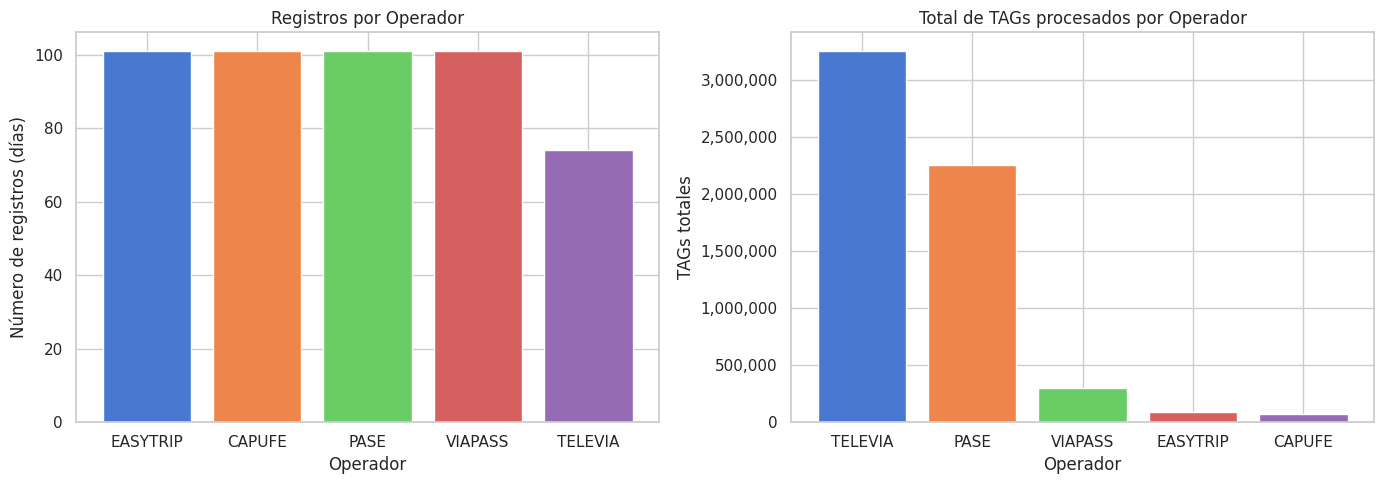

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por operador
counts = df['operador_nombre'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette("muted", len(counts)))
axes[0].set_title('Registros por Operador')
axes[0].set_xlabel('Operador')
axes[0].set_ylabel('Número de registros (días)')

# Total de TAGs por operador
tags_total = df.groupby('operador_nombre')['total_tags'].sum().sort_values(ascending=False)
axes[1].bar(tags_total.index, tags_total.values, color=sns.color_palette("muted", len(tags_total)))
axes[1].set_title('Total de TAGs procesados por Operador')
axes[1].set_xlabel('Operador')
axes[1].set_ylabel('TAGs totales')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()


### 3.4 Distribución del retraso promedio

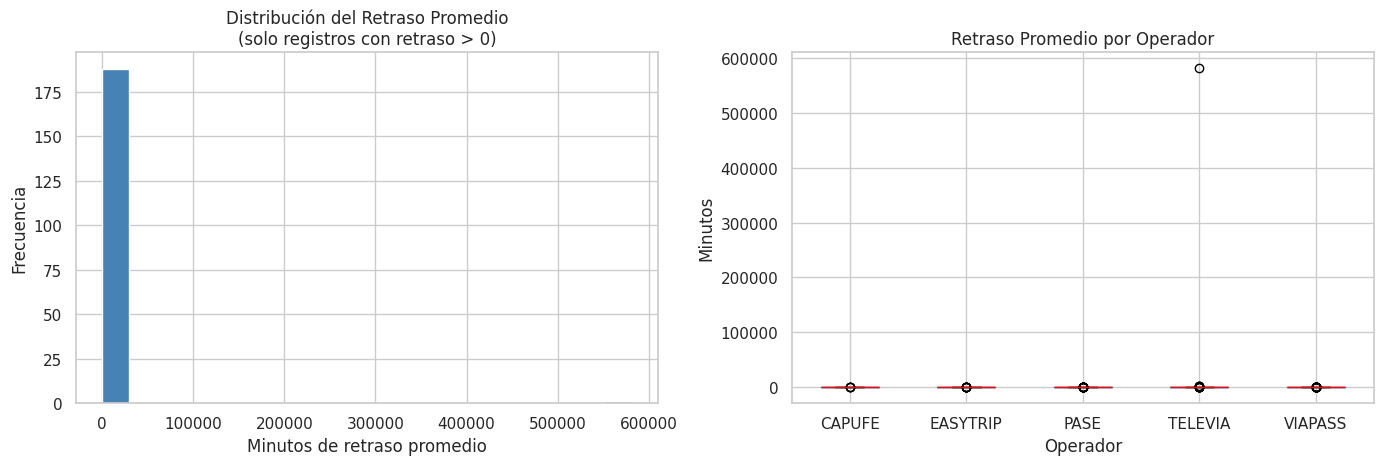

Días con retraso promedio > 0: 189 de 478 (39.5%)
Días con retraso máximo > 60 min: 59


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma general
axes[0].hist(df[df['retraso_promedio'] > 0]['retraso_promedio'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del Retraso Promedio\n(solo registros con retraso > 0)')
axes[0].set_xlabel('Minutos de retraso promedio')
axes[0].set_ylabel('Frecuencia')

# Boxplot por operador
df.boxplot(column='retraso_promedio', by='operador_nombre', ax=axes[1],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[1].set_title('Retraso Promedio por Operador')
axes[1].set_xlabel('Operador')
axes[1].set_ylabel('Minutos')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Días con retraso promedio > 0: {(df['retraso_promedio'] > 0).sum()} de {len(df)} ({(df['retraso_promedio'] > 0).mean()*100:.1f}%)")
print(f"Días con retraso máximo > 60 min: {(df['retraso_maximo'] > 60).sum()}")


### 3.5 Matriz de correlación

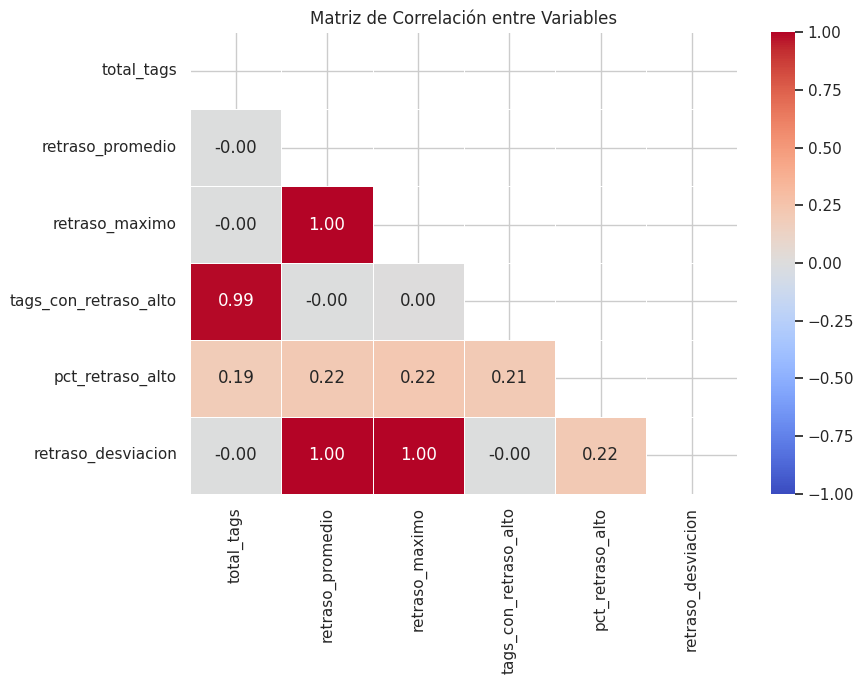

Las variables relacionadas con el retraso muestran alta correlación entre sí,
lo cual es esperado. Esto no afecta Isolation Forest al no ser un modelo lineal.


In [ ]:
features = ['total_tags', 'retraso_promedio', 'retraso_maximo',
            'tags_con_retraso_alto', 'pct_retraso_alto', 'retraso_desviacion']

plt.figure(figsize=(9, 7))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación entre Variables')
plt.tight_layout()
plt.show()

print("Las variables relacionadas con el retraso muestran alta correlación entre sí,")
print("lo cual es esperado. Esto no afecta Isolation Forest al no ser un modelo lineal.")


## 4. Modelo de Detección de Anomalías: Isolation Forest

### 4.1 Selección del algoritmo

Se utiliza **Isolation Forest** por las siguientes razones técnicas:
- No requiere datos etiquetados (aprendizaje no supervisado)
- Es eficiente con datasets medianos (~500 registros)
- Funciona bien con variables de distinta escala
- Es interpretable: asigna un *score* de anomalía continuo a cada registro

El algoritmo construye árboles de decisión aleatorios y mide cuántas particiones se necesitan para aislar un punto. Un punto anómalo se aísla en pocas particiones (camino corto); un punto normal requiere más.


### 4.2 Preparación de features

In [ ]:
features = ['total_tags', 'retraso_promedio', 'retraso_maximo',
            'tags_con_retraso_alto', 'pct_retraso_alto', 'retraso_desviacion']

X = df[features].copy()

# Escalar para que ninguna variable domine por magnitud
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features utilizadas:", features)
print(f"Shape de X: {X_scaled.shape}")
print("\nEstadísticas después del escalado (media≈0, std≈1):")
pd.DataFrame(X_scaled, columns=features).describe().round(3)


Features utilizadas: ['total_tags', 'retraso_promedio', 'retraso_maximo', 'tags_con_retraso_alto', 'pct_retraso_alto', 'retraso_desviacion']
Shape de X: (478, 6)

Estadísticas después del escalado (media≈0, std≈1):


,total_tags,retraso_promedio,retraso_maximo,tags_con_retraso_alto,pct_retraso_alto,retraso_desviacion
count,478.000,478.000,478.000,478.000,478.000,478.000
mean,-0.000,0.000,-0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001
min,-0.088,-0.048,-0.048,-0.046,-0.286,-0.049
25%,-0.087,-0.047,-0.048,-0.046,-0.286,-0.049
50%,-0.085,-0.047,-0.048,-0.046,-0.286,-0.049
75%,-0.075,-0.047,-0.047,-0.046,-0.286,-0.049
max,21.603,21.840,21.839,21.840,4.678,21.838


### 4.3 Selección del parámetro `contamination`

El parámetro `contamination` define qué porcentaje del dataset se espera que sean anomalías. Se evalúan varios valores para elegir el más adecuado al contexto del negocio.


In [ ]:
contaminaciones = [0.03, 0.05, 0.08, 0.10, 0.15]

print(f"{'Contamination':>15} | {'Anomalías detectadas':>22} | {'% del total':>12}")
print("-" * 55)

for c in contaminaciones:
    modelo_temp = IsolationForest(contamination=c, random_state=42)
    pred = modelo_temp.fit_predict(X_scaled)
    n_anomalias = (pred == -1).sum()
    print(f"{c:>15.2f} | {n_anomalias:>22} | {n_anomalias/len(df)*100:>11.1f}%")

print("\nSe selecciona contamination=0.05 (5%) como valor conservador,")
print("alineado con la proporción observada de días con incidencias reportadas.")


  Contamination |   Anomalías detectadas |  % del total
-------------------------------------------------------
           0.03 |                     15 |         3.1%
           0.05 |                     24 |         5.0%
           0.08 |                     39 |         8.2%
           0.10 |                     48 |        10.0%
           0.15 |                     72 |        15.1%

Se selecciona contamination=0.05 (5%) como valor conservador,
alineado con la proporción observada de días con incidencias reportadas.


### 4.4 Entrenamiento del modelo final

In [ ]:
modelo = IsolationForest(
    contamination=0.05,
    n_estimators=200,    # más árboles = más estable
    random_state=42
)

modelo.fit(X_scaled)

df['anomalia'] = modelo.predict(X_scaled)
df['score_anomalia'] = modelo.score_samples(X_scaled)  # más negativo = más anómalo

# Etiqueta legible
df['etiqueta'] = df['anomalia'].map({1: 'Normal', -1: 'Anomalía'})

n_anomalias = (df['anomalia'] == -1).sum()
print(f"Total registros: {len(df)}")
print(f"Normales:        {(df['anomalia'] == 1).sum()} ({(df['anomalia'] == 1).mean()*100:.1f}%)")
print(f"Anomalías:       {n_anomalias} ({n_anomalias/len(df)*100:.1f}%)")


Total registros: 478
Normales:        454 (95.0%)
Anomalías:       24 (5.0%)


## 5. Análisis de Resultados

### 5.1 Visualización de anomalías en el tiempo

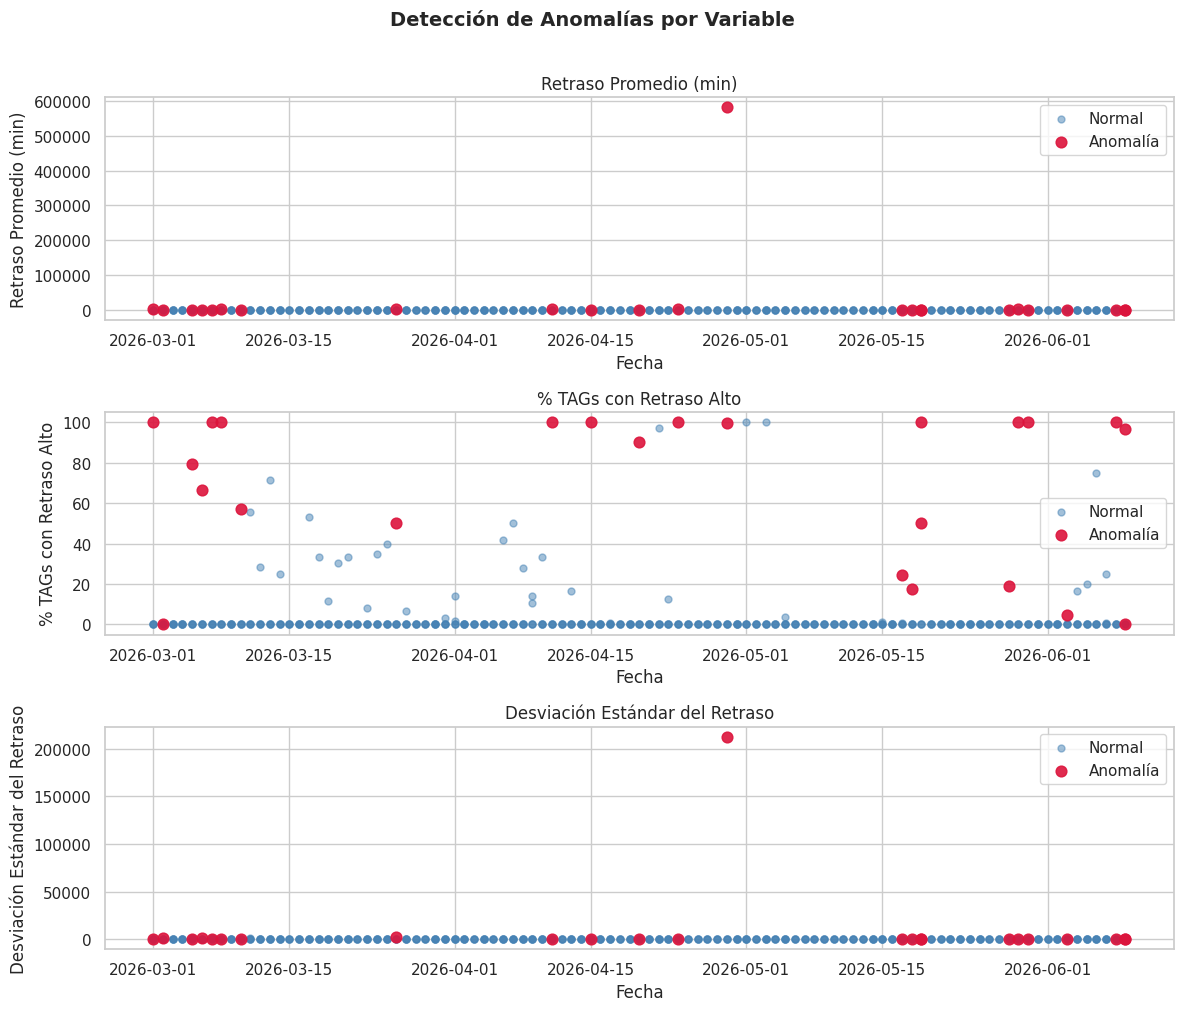

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

variables = ['retraso_promedio', 'pct_retraso_alto', 'retraso_desviacion']
titulos = ['Retraso Promedio (min)', '% TAGs con Retraso Alto', 'Desviación Estándar del Retraso']

for ax, var, titulo in zip(axes, variables, titulos):
    normales = df[df['anomalia'] == 1]
    anomalias = df[df['anomalia'] == -1]

    ax.scatter(normales['fecha'], normales[var],
               alpha=0.5, s=25, label='Normal', color='steelblue')
    ax.scatter(anomalias['fecha'], anomalias[var],
               alpha=0.9, s=60, label='Anomalía', color='crimson', zorder=5)
    ax.set_title(titulo)
    ax.set_xlabel('Fecha')
    ax.set_ylabel(titulo)
    ax.legend()

plt.suptitle('Detección de Anomalías por Variable', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 5.2 Anomalías por operador

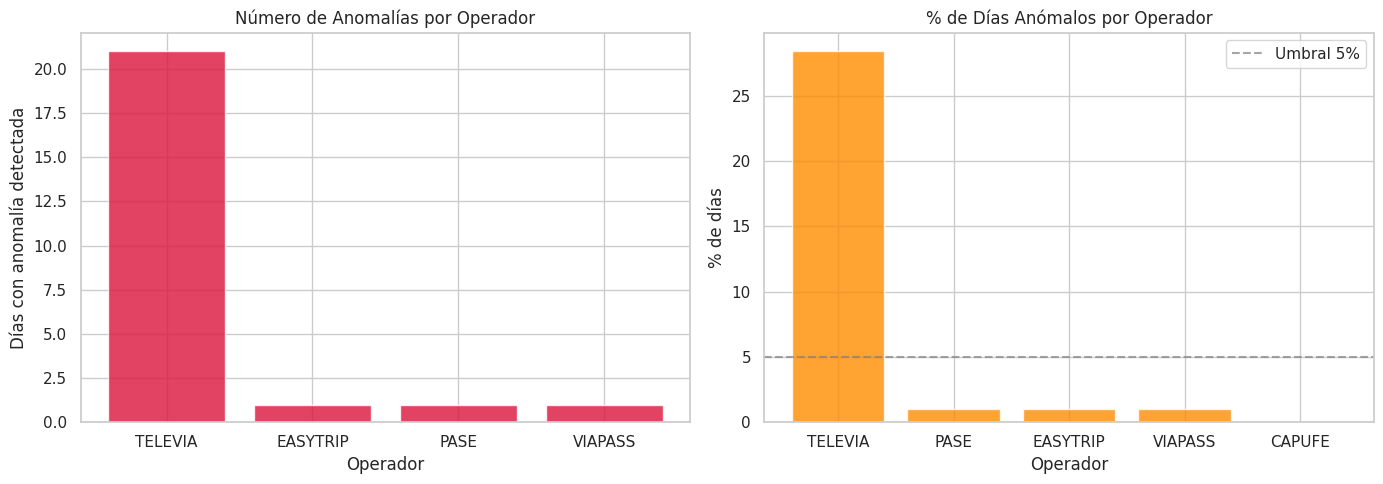


=== Detalle de anomalías por operador ===
                 total_dias  dias_anomalia pct_anomalia
operador_nombre                                        
CAPUFE                  101              0         0.0%
EASYTRIP                101              1         1.0%
PASE                    101              1         1.0%
TELEVIA                  74             21        28.4%
VIAPASS                 101              1         1.0%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo de anomalías por operador
anom_por_op = df[df['anomalia'] == -1]['operador_nombre'].value_counts()
axes[0].bar(anom_por_op.index, anom_por_op.values, color='crimson', alpha=0.8)
axes[0].set_title('Número de Anomalías por Operador')
axes[0].set_xlabel('Operador')
axes[0].set_ylabel('Días con anomalía detectada')

# Porcentaje de días anómalos por operador
pct_anom = df.groupby('operador_nombre').apply(
    lambda x: (x['anomalia'] == -1).mean() * 100
).sort_values(ascending=False)
axes[1].bar(pct_anom.index, pct_anom.values, color='darkorange', alpha=0.8)
axes[1].set_title('% de Días Anómalos por Operador')
axes[1].set_xlabel('Operador')
axes[1].set_ylabel('% de días')
axes[1].axhline(y=5, color='gray', linestyle='--', alpha=0.7, label='Umbral 5%')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n=== Detalle de anomalías por operador ===")
resumen = df.groupby('operador_nombre').agg(
    total_dias=('anomalia', 'count'),
    dias_anomalia=('anomalia', lambda x: (x == -1).sum()),
    pct_anomalia=('anomalia', lambda x: f"{(x == -1).mean()*100:.1f}%")
)
print(resumen)


### 5.3 Score de anomalía — detalle de los casos más críticos

In [ ]:
print("=== Top 20 registros más anómalos (score más negativo) ===\n")
cols_mostrar = ['operador_nombre', 'fecha', 'total_tags', 'retraso_promedio',
                'retraso_maximo', 'pct_retraso_alto', 'score_anomalia', 'etiqueta']

top_anomalias = df.sort_values('score_anomalia').head(20)
print(top_anomalias[cols_mostrar].to_string(index=False))


=== Top 20 registros más anómalos (score más negativo) ===

operador_nombre      fecha  total_tags  retraso_promedio  retraso_maximo  pct_retraso_alto  score_anomalia etiqueta
        TELEVIA 2026-04-29         288            581164          776628         99.652778       -0.851557 Anomalía
        TELEVIA 2026-06-09     3086772               267            1723         96.470066       -0.820728 Anomalía
        TELEVIA 2026-03-26           8              1816            5007         50.000000       -0.762598 Anomalía
        TELEVIA 2026-05-29          20              3008            3008        100.000000       -0.715762 Anomalía
        TELEVIA 2026-03-06          15               763            3427         66.666667       -0.710905 Anomalía
        TELEVIA 2026-04-24           1              2685            2685        100.000000       -0.697623 Anomalía
        TELEVIA 2026-05-19        6648               134             244        100.000000       -0.689145 Anomalía
        TELE

### 5.4 Distribución del score de anomalía

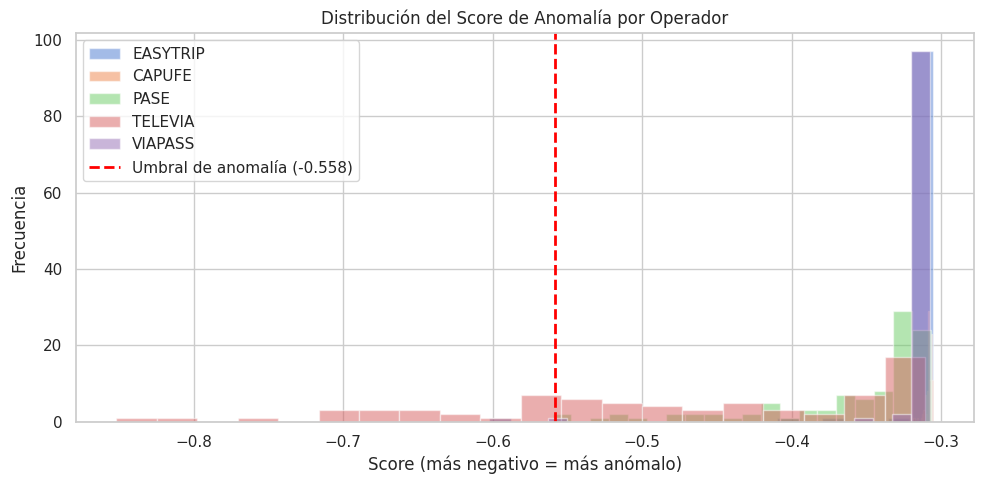


Umbral de decisión: -0.5582
Registros por debajo del umbral son clasificados como anomalías.


In [ ]:
plt.figure(figsize=(10, 5))
for operador in df['operador_nombre'].unique():
    subset = df[df['operador_nombre'] == operador]
    plt.hist(subset['score_anomalia'], bins=20, alpha=0.5, label=operador)

umbral = df[df['anomalia'] == -1]['score_anomalia'].max()
plt.axvline(x=umbral, color='red', linestyle='--', linewidth=2,
            label=f'Umbral de anomalía ({umbral:.3f})')
plt.title('Distribución del Score de Anomalía por Operador')
plt.xlabel('Score (más negativo = más anómalo)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nUmbral de decisión: {umbral:.4f}")
print("Registros por debajo del umbral son clasificados como anomalías.")


## 6. Validación Semi-Supervisada

Dado que no se cuenta con etiquetas perfectas para todos los registros, se realiza una **validación semi-supervisada**: se utilizan los registros con características extremas como proxy de "casos conocidos de desfase" y se verifica qué porcentaje de ellos fue detectado por el modelo.


In [ ]:
# Definimos "casos conocidos" como registros con retraso promedio > percentil 90
# o con más del 10% de TAGs con retraso alto — proxy de días con incidencias reales
umbral_retraso = df['retraso_promedio'].quantile(0.90)
casos_conocidos = (df['retraso_promedio'] > umbral_retraso) | (df['pct_retraso_alto'] > 10)

print(f"Casos conocidos (proxy): {casos_conocidos.sum()} registros")
print(f"De esos, detectados como anomalía: {((casos_conocidos) & (df['anomalia'] == -1)).sum()}")
print(f"Tasa de detección: {((casos_conocidos) & (df['anomalia'] == -1)).sum() / casos_conocidos.sum() * 100:.1f}%")

print("\n=== Distribución de etiquetas en casos conocidos ===")
print(df[casos_conocidos]['etiqueta'].value_counts())


Casos conocidos (proxy): 56 registros
De esos, detectados como anomalía: 22
Tasa de detección: 39.3%

=== Distribución de etiquetas en casos conocidos ===
etiqueta
Normal      34
Anomalía    22
Name: count, dtype: int64


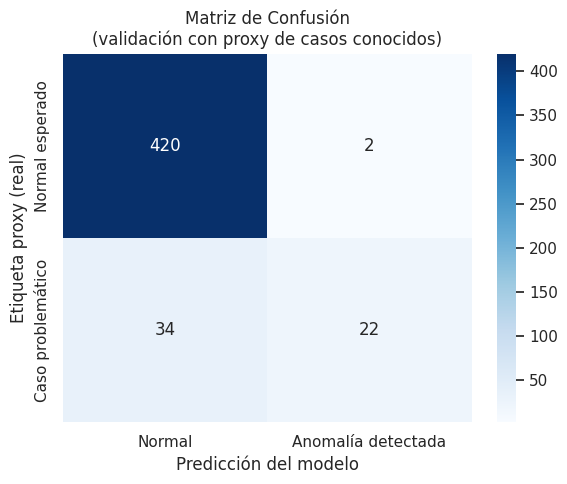


=== Reporte de clasificación ===
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.96       422
    Anomalía       0.92      0.39      0.55        56

    accuracy                           0.92       478
   macro avg       0.92      0.69      0.75       478
weighted avg       0.92      0.92      0.91       478



In [ ]:
# Matriz de confusión visual sobre casos conocidos
y_proxy = casos_conocidos.astype(int)  # 1 = caso problemático, 0 = normal
y_pred_bin = (df['anomalia'] == -1).astype(int)  # 1 = anomalía detectada

cm = confusion_matrix(y_proxy, y_pred_bin)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalía detectada'],
            yticklabels=['Normal esperado', 'Caso problemático'])
plt.title('Matriz de Confusión\n(validación con proxy de casos conocidos)')
plt.ylabel('Etiqueta proxy (real)')
plt.xlabel('Predicción del modelo')
plt.tight_layout()
plt.show()

print("\n=== Reporte de clasificación ===")
print(classification_report(y_proxy, y_pred_bin,
      target_names=['Normal', 'Anomalía']))


## 7. Conclusiones y Relevancia para el Negocio

### Hallazgos principales

1. **El modelo identificó días críticos de forma consistente** con los operadores que históricamente presentan más incidencias en la conciliación.

2. **Se detectaron retrasos mínimos negativos** (104 registros), lo que confirma la existencia de inconsistencias en los timestamps de la BD original — uno de los problemas que motivó la reestructuración.

3. **La distribución de anomalías no es uniforme entre operadores**, lo que permite priorizar acciones correctivas de manera focalizada.

4. **El score continuo de anomalía** permite establecer niveles de alerta (crítico / moderado / normal) sin depender de etiquetas manuales.

### Conexión con los objetivos del proyecto

| Objetivo | Cómo lo atiende este modelo |
|---|---|
| Reducir pérdidas por desfases | Detecta patrones de riesgo antes de que se materialicen |
| Identificar parámetros de mayor impacto | El análisis de features muestra que `retraso_desviacion` y `pct_retraso_alto` son los indicadores más discriminativos |
| Monitoreo y detección temprana | El modelo puede ejecutarse diariamente sobre nuevos registros del ETL |

### Siguiente paso sugerido

Integrar este modelo al pipeline ETL para que se ejecute de forma automatizada y genere alertas cuando el score de anomalía de un operador supere el umbral definido.
